# 05 · Dynamic Hydrographs

Produces publication-quality hydrographs for any study catchment using **matplotlib**.  
Select a station in **Section 4**, run all cells, and the figures appear inline and are saved to `results/hydrographs/`.

### Layout
| Subplot | Content |
|---|---|
| Top (75 %) | Specific streamflow Q/A — observed · HBV · TFT median + quantile envelope |
| Bottom (25 %) | Daily precipitation (inverted bar chart) |

A QQ-plot (reliability diagram) is produced separately for any available TFT output.

### What it needs
| Path | Required? | Content |
|---|---|---|
| `data/hydrological/<STATION>.csv` | yes | Observed Q and Q/A |
| `data/meteorological/<STATION>.csv` | yes | ERA5-Land tp, t2m |
| `data/geomorphological/catchment_descriptors.csv` | yes | Catchment area |
| `results/hbv/<STATION>/<STATION>_HBV_simulation.csv` | optional | HBV simulation |
| `results/tft/<STATION>_ungauged.p` | optional | TFT ungauged quantile predictions |
| `results/tft/<STATION>_specialized.p` | optional | TFT specialized quantile predictions |

Models appear automatically once their output files exist — nothing else to change.

## 0 · Imports and paths

In [1]:
import pickle
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT      = Path("..")
HYDRO_DIR = ROOT / "data" / "hydrological"
METEO_DIR = ROOT / "data" / "meteorological"
GEO_FILE  = ROOT / "data" / "geomorphological" / "catchment_descriptors.csv"
HBV_DIR   = ROOT / "results" / "hbv"
TFT_DIR   = ROOT / "results" / "tft"
OUT_DIR   = ROOT / "results" / "hydrographs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Catchment descriptors ──────────────────────────────────────────────────────
desc = pd.read_csv(GEO_FILE, sep=";")
desc["station"] = desc["Group"].str.replace("/", "_", regex=False)
desc = desc.set_index("station")

ALL_STATIONS = sorted([p.stem for p in HYDRO_DIR.glob("*.csv")])
print(f"matplotlib {matplotlib.__version__}")
print(f"Stations available: {len(ALL_STATIONS)}")

matplotlib 3.7.3
Stations available: 53


## 1 · Style constants

In [2]:
# Quantile bands: (lower_p, upper_p, RGBA fill colour, legend label)
# Opacity increases toward the median so inner bands appear darker.
BANDS_UNG = [
    (0.01, 0.99, (0.17, 0.50, 0.83, 0.10), "1-99 %"),
    (0.05, 0.95, (0.17, 0.50, 0.83, 0.18), "5-95 %"),
    (0.10, 0.90, (0.17, 0.50, 0.83, 0.26), "10-90 %"),
    (0.25, 0.75, (0.17, 0.50, 0.83, 0.38), "25-75 %"),
    (0.40, 0.60, (0.17, 0.50, 0.83, 0.55), "40-60 %"),
]
BANDS_SPE = [
    (0.01, 0.99, (0.15, 0.66, 0.27, 0.09)),
    (0.05, 0.95, (0.15, 0.66, 0.27, 0.16)),
    (0.10, 0.90, (0.15, 0.66, 0.27, 0.23)),
    (0.25, 0.75, (0.15, 0.66, 0.27, 0.35)),
    (0.40, 0.60, (0.15, 0.66, 0.27, 0.50)),
]

C = {
    "observed":       "black",
    "hbv":            "#E87722",
    "tft_ung_median": "#2B7FD4",
    "tft_spe_median": "#27A844",
    "precip":         "steelblue",
}

plt.rcParams.update({
    "figure.dpi":        120,
    "savefig.dpi":       150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linewidth":    0.5,
    "font.size":         10,
})

print("Style constants set.")

Style constants set.


## 2 · Data loaders

In [3]:
def load_observed(station):
    df = pd.read_csv(HYDRO_DIR / f"{station}.csv", parse_dates=["Event date"])
    return df.rename(columns={"Event date": "date", "Q": "Q_m3s", "Q/A": "Q_A"})[["date", "Q_m3s", "Q_A"]]


def load_meteo(station):
    df = pd.read_csv(METEO_DIR / f"{station}.csv", parse_dates=["Event date"])
    return df.rename(columns={"Event date": "date"})


def load_hbv(station, area_km2):
    """Returns DataFrame with columns [date, Q_HBV_A] or None."""
    path = HBV_DIR / station / f"{station}_HBV_simulation.csv"
    if not path.exists():
        return None
    df = pd.read_csv(path, parse_dates=["Event date"])
    df = df.rename(columns={"Event date": "date", "0": "Q_HBV_m3s"})
    df["Q_HBV_A"] = df["Q_HBV_m3s"] / area_km2 * 1000
    return df[["date", "Q_HBV_A"]]


def load_tft(station, setting):
    """Returns dict {dates, observed, quantiles} or None.

    Expected pickle structure::

        {
          'dates':     DatetimeIndex or array of datetime,
          'observed':  np.ndarray  (Q/A, 10^-3 m3 s-1 km-2),
          'quantiles': {float -> np.ndarray}
        }
    """
    path = TFT_DIR / f"{station}_{setting}.p"
    if not path.exists():
        return None
    with open(path, "rb") as f:
        return pickle.load(f)


print("Loaders ready.")

Loaders ready.


## 3 · Metric helpers

In [ ]:
def _clean(obs, sim):
    o, s = np.asarray(obs, float), np.asarray(sim, float)
    m = np.isfinite(o) & np.isfinite(s)
    return o[m], s[m]

def nse(obs, sim):
    o, s = _clean(obs, sim)
    return float(1 - np.sum((o - s)**2) / np.sum((o - np.mean(o))**2))

def kge(obs, sim):
    o, s = _clean(obs, sim)
    r     = float(np.corrcoef(o, s)[0, 1])
    beta  = float(np.mean(s) / np.mean(o))
    omega = float((np.std(s) / np.mean(s)) / (np.std(o) / np.mean(o)))
    return float(1 - np.sqrt((r-1)**2 + (beta-1)**2 + (omega-1)**2))

def alpha_reliability(obs, quantiles):
    """Reliability alpha (Renard et al., 2010). Optimal = 1."""
    levels = sorted(quantiles.keys())
    n      = len(obs)
    pit    = np.array([
        float(np.interp(obs[i], [quantiles[p][i] for p in levels], levels,
                        left=0.0, right=1.0))
        for i in range(n)
    ])
    pit_s = np.sort(pit)
    theo  = (np.arange(1, n + 1) - 0.5) / n
    return float(1 - 2 * np.mean(np.abs(pit_s - theo)))

print("Metric helpers ready.")

## 4 · STATION SELECTION — edit here, then run all cells below

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#   EDIT THESE VARIABLES, then Kernel > Restart & Run Below
# ─────────────────────────────────────────────────────────────────────────────

STATION     = "03J_01H"      # station code with underscore, e.g. "03J_01H"

DATE_START  = "1990-10-01"   # start of display window  (None = full record)
DATE_END    = "1992-09-30"   # end of display window    (None = full record)

SHOW_HBV             = True  # show HBV if its CSV exists
SHOW_TFT_UNGAUGED    = True  # show TFT ungauged if .p exists
SHOW_TFT_SPECIALIZED = True  # show TFT specialized if .p exists

FIG_SIZE    = (14, 7)        # figure size in inches
SAVE_FORMAT = "pdf"          # "pdf", "png", or "svg"  (None to skip saving)
SAVE_DPI    = 300            # DPI for raster formats

# ─────────────────────────────────────────────────────────────────────────────

assert STATION in ALL_STATIONS, (
    f"Station '{STATION}' not found.\nAvailable: {ALL_STATIONS}"
)
area_km2   = float(desc.loc[STATION, "area"]) if STATION in desc.index else None
snirh_code = STATION.replace("_", "/")

if STATION in desc.index:
    r = desc.loc[STATION]
    print(f"Station  : {snirh_code}")
    print(f"Cluster  : {r['cluster']}")
    print(f"Area     : {area_km2:.2f} km2")
    print(f"Elevation: {r['mean_elev']:.0f} m (mean)")
    print(f"Precip.  : {r['annual_avg_tp']:.0f} mm/yr (ERA5-Land mean)")
print(f"Window   : {DATE_START or 'full'} to {DATE_END or 'full'}")

Station  : 03J/01H
Cluster  : A
Area     : 103.13 km2
Elevation: 1065 m (mean)
Precip.  : 941 mm/yr (ERA5-Land mean)
Window   : 1990-10-01 to 1992-09-30


## 5 · Load data

In [5]:
obs_df   = load_observed(STATION)
meteo_df = load_meteo(STATION)
hbv_df   = load_hbv(STATION, area_km2) if (SHOW_HBV and area_km2) else None
tft_ung  = load_tft(STATION, "ungauged")    if SHOW_TFT_UNGAUGED    else None
tft_spe  = load_tft(STATION, "specialized") if SHOW_TFT_SPECIALIZED else None


def window_df(df, start, end, col="date"):
    if start:
        df = df[df[col] >= pd.Timestamp(start)]
    if end:
        df = df[df[col] <= pd.Timestamp(end)]
    return df.copy()


def window_tft(tft, start, end):
    if tft is None:
        return None
    dates = pd.DatetimeIndex(tft["dates"])
    mask  = np.ones(len(dates), bool)
    if start:
        mask &= dates >= pd.Timestamp(start)
    if end:
        mask &= dates <= pd.Timestamp(end)
    return {
        "dates":     dates[mask],
        "observed":  np.asarray(tft["observed"])[mask],
        "quantiles": {p: np.asarray(q)[mask] for p, q in tft["quantiles"].items()},
    }


obs_df   = window_df(obs_df,   DATE_START, DATE_END)
meteo_df = window_df(meteo_df, DATE_START, DATE_END)
if hbv_df is not None:
    hbv_df = window_df(hbv_df, DATE_START, DATE_END)
tft_ung  = window_tft(tft_ung, DATE_START, DATE_END)
tft_spe  = window_tft(tft_spe, DATE_START, DATE_END)


def _n(x):
    if x is None:
        return "not available"
    return f"{len(x) if not isinstance(x, dict) else len(x['dates']):,} days"

print(f"Observed        : {_n(obs_df)}")
print(f"HBV             : {_n(hbv_df)}")
print(f"TFT ungauged    : {_n(tft_ung)}")
print(f"TFT specialized : {_n(tft_spe)}")

Observed        : 731 days
HBV             : 731 days
TFT ungauged    : not available
TFT specialized : not available


## 6 · Hydrograph

NameError: name 'nse' is not defined

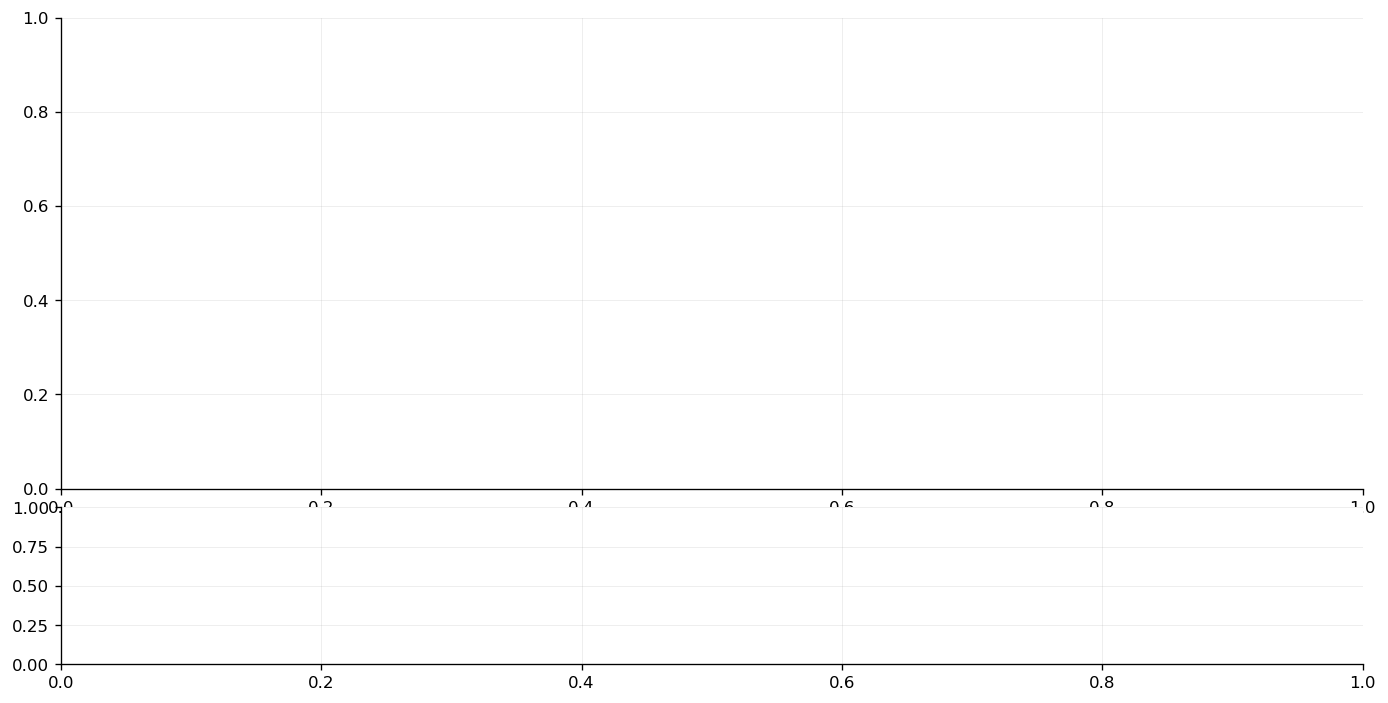

: 

In [ ]:
fig = plt.figure(figsize=FIG_SIZE)
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# ── Quantile bands (TFT ungauged, blue) ───────────────────────────────────────
if tft_ung is not None:
    q = tft_ung["quantiles"]
    d = tft_ung["dates"]
    for lo, hi, color, _ in BANDS_UNG:
        if lo in q and hi in q:
            ax1.fill_between(d, q[lo], q[hi], color=color, linewidth=0, zorder=1)

# ── Quantile bands (TFT specialized, green) ───────────────────────────────────
if tft_spe is not None:
    q = tft_spe["quantiles"]
    d = tft_spe["dates"]
    for lo, hi, color in BANDS_SPE:
        if lo in q and hi in q:
            ax1.fill_between(d, q[lo], q[hi], color=color, linewidth=0, zorder=2)

# ── HBV ───────────────────────────────────────────────────────────────────────
hbv_nse = hbv_kge = None
if hbv_df is not None:
    mg = obs_df.merge(hbv_df, on="date", how="inner")
    hbv_nse = nse(mg["Q_A"].values, mg["Q_HBV_A"].values)
    hbv_kge = kge(mg["Q_A"].values, mg["Q_HBV_A"].values)
    ax1.plot(hbv_df["date"], hbv_df["Q_HBV_A"],
             color=C["hbv"], lw=1.2, zorder=3)

# ── TFT median lines ──────────────────────────────────────────────────────────
tft_ung_nse = tft_ung_kge = None
if tft_ung is not None and 0.50 in tft_ung["quantiles"]:
    med = tft_ung["quantiles"][0.50]
    tft_ung_nse = nse(tft_ung["observed"], med)
    tft_ung_kge = kge(tft_ung["observed"], med)
    ax1.plot(tft_ung["dates"], med,
             color=C["tft_ung_median"], lw=1.5, ls="--", zorder=4)

tft_spe_nse = tft_spe_kge = None
if tft_spe is not None and 0.50 in tft_spe["quantiles"]:
    med = tft_spe["quantiles"][0.50]
    tft_spe_nse = nse(tft_spe["observed"], med)
    tft_spe_kge = kge(tft_spe["observed"], med)
    ax1.plot(tft_spe["dates"], med,
             color=C["tft_spe_median"], lw=1.5, ls="-.", zorder=4)

# ── Observed (drawn last so it sits on top) ────────────────────────────────────
ax1.plot(obs_df["date"], obs_df["Q_A"],
         color=C["observed"], lw=1.2, zorder=5)

# ── Streamflow axis ───────────────────────────────────────────────────────────
ax1.set_ylabel("q  (1e-3 m3 s-1 km-2)", fontsize=11)
ax1.tick_params(labelbottom=False)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [Line2D([0], [0], color=C["observed"], lw=1.2, label="Observed")]

if hbv_df is not None:
    lbl = f"HBV  (NSE={hbv_nse:.2f}, KGE={hbv_kge:.2f})" if hbv_nse is not None else "HBV"
    handles.append(Line2D([0], [0], color=C["hbv"], lw=1.2, label=lbl))

if tft_ung is not None:
    lbl = (f"TFT ungauged  (NSE={tft_ung_nse:.2f}, KGE={tft_ung_kge:.2f})"
           if tft_ung_nse is not None else "TFT ungauged")
    handles.append(Line2D([0], [0], color=C["tft_ung_median"], lw=1.5, ls="--", label=lbl))
    for lo, hi, color, band_lbl in BANDS_UNG:
        handles.append(Patch(facecolor=color, edgecolor="none", label=band_lbl))

if tft_spe is not None:
    lbl = (f"TFT specialized  (NSE={tft_spe_nse:.2f}, KGE={tft_spe_kge:.2f})"
           if tft_spe_nse is not None else "TFT specialized")
    handles.append(Line2D([0], [0], color=C["tft_spe_median"], lw=1.5, ls="-.", label=lbl))

ax1.legend(handles=handles, fontsize=8.5,
           ncol=max(1, len(handles) // 2),
           loc="upper right", framealpha=0.88)

# ── Precipitation panel ───────────────────────────────────────────────────────
ax2.bar(meteo_df["date"], meteo_df["tp"],
        color=C["precip"], alpha=0.65, width=1.0)
ax2.invert_yaxis()
ax2.set_ylabel("P (mm)", fontsize=11)
ax2.set_xlabel("Date",   fontsize=11)

# ── Date tick format (auto-scaled to window length) ───────────────────────────
total_days = (obs_df["date"].max() - obs_df["date"].min()).days
if total_days <= 400:
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
elif total_days <= 1500:
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
else:
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.setp(ax2.get_xticklabels(), rotation=30, ha="right", fontsize=9)

fig.suptitle(f"Station {snirh_code}", fontsize=13, y=0.99)

if SAVE_FORMAT:
    out_path = OUT_DIR / f"{STATION}_hydrograph.{SAVE_FORMAT}"
    fig.savefig(out_path, dpi=SAVE_DPI, bbox_inches="tight")
    print(f"Saved: {out_path}")

plt.show()

## 7 · QQ-plot (reliability diagram)

Only produced when TFT output is available. A perfectly calibrated model aligns with the 1:1 diagonal.

In [ ]:
for tft_data, lbl, col in [
    (tft_ung, "TFT_ungauged",    C["tft_ung_median"]),
    (tft_spe, "TFT_specialized", C["tft_spe_median"]),
]:
    if tft_data is None:
        print(f"{lbl}: no data, QQ-plot skipped.")
        continue

    obs_arr = np.asarray(tft_data["observed"], float)
    quant   = tft_data["quantiles"]
    levels  = sorted(quant.keys())
    n       = len(obs_arr)

    pit = np.array([
        float(np.interp(obs_arr[i],
                        [quant[p][i] for p in levels], levels,
                        left=0.0, right=1.0))
        for i in range(n)
    ])
    pit_s = np.sort(pit)
    theo  = (np.arange(1, n + 1) - 0.5) / n
    alpha_val = float(1 - 2 * np.mean(np.abs(pit_s - theo)))

    fig_qq, ax_qq = plt.subplots(figsize=(4.5, 4.5))
    ax_qq.plot([0, 1], [0, 1], "k:",  lw=1.0, label="Desired (1:1)")
    ax_qq.plot(theo, pit_s,    color=col, lw=2.0,
               label=f"{lbl.replace('_', ' ')}  alpha={alpha_val:.3f}")
    ax_qq.set_xlabel("Theoretical quantile of U[0,1]", fontsize=10)
    ax_qq.set_ylabel("Observed quantile of U[0,1]",    fontsize=10)
    ax_qq.set_xlim(0, 1)
    ax_qq.set_ylim(0, 1)
    ax_qq.set_aspect("equal")
    ax_qq.legend(fontsize=9)
    ax_qq.set_title(f"Reliability -- {snirh_code}", fontsize=11)
    fig_qq.tight_layout()

    if SAVE_FORMAT:
        out = OUT_DIR / f"{STATION}_{lbl}_QQ.{SAVE_FORMAT}"
        fig_qq.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
        print(f"Saved: {out}")

    plt.show()

## 8 · Batch export — all stations

Generates one figure per station for every available model output.  
Set `BATCH_EXPORT = True` to run. Figures are saved to `results/hydrographs/`.

In [ ]:
BATCH_EXPORT      = False   # <- change to True to process all stations
BATCH_FORMAT      = "pdf"
BATCH_DATE_START  = None    # common window; None = full record
BATCH_DATE_END    = None

if BATCH_EXPORT:
    errors = []
    for stn in ALL_STATIONS:
        if stn not in desc.index:
            continue
        a = float(desc.loc[stn, "area"])
        try:
            o  = window_df(load_observed(stn), BATCH_DATE_START, BATCH_DATE_END)
            m  = window_df(load_meteo(stn),    BATCH_DATE_START, BATCH_DATE_END)
            h  = load_hbv(stn, a)
            if h is not None:
                h = window_df(h, BATCH_DATE_START, BATCH_DATE_END)
            tu = window_tft(load_tft(stn, "ungauged"),    BATCH_DATE_START, BATCH_DATE_END)
            ts = window_tft(load_tft(stn, "specialized"), BATCH_DATE_START, BATCH_DATE_END)

            # Re-use the full figure-building block above as a local closure
            # by calling a thin wrapper that mirrors Section 6 exactly.
            fig_b = plt.figure(figsize=FIG_SIZE)
            gs_b  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
            ax1_b = fig_b.add_subplot(gs_b[0])
            ax2_b = fig_b.add_subplot(gs_b[1], sharex=ax1_b)

            if tu is not None:
                q = tu["quantiles"]
                for lo, hi, color, _ in BANDS_UNG:
                    if lo in q and hi in q:
                        ax1_b.fill_between(tu["dates"], q[lo], q[hi],
                                           color=color, linewidth=0, zorder=1)
                if 0.50 in q:
                    ax1_b.plot(tu["dates"], q[0.50],
                               color=C["tft_ung_median"], lw=1.5, ls="--", zorder=4)
            if ts is not None:
                q = ts["quantiles"]
                for lo, hi, color in BANDS_SPE:
                    if lo in q and hi in q:
                        ax1_b.fill_between(ts["dates"], q[lo], q[hi],
                                           color=color, linewidth=0, zorder=2)
                if 0.50 in q:
                    ax1_b.plot(ts["dates"], q[0.50],
                               color=C["tft_spe_median"], lw=1.5, ls="-.", zorder=4)
            if h is not None:
                ax1_b.plot(h["date"], h["Q_HBV_A"],
                           color=C["hbv"], lw=1.2, zorder=3)
            ax1_b.plot(o["date"], o["Q_A"],
                       color=C["observed"], lw=1.2, zorder=5)
            ax1_b.set_ylabel("q  (1e-3 m3 s-1 km-2)", fontsize=10)
            ax1_b.tick_params(labelbottom=False)

            ax2_b.bar(m["date"], m["tp"],
                      color=C["precip"], alpha=0.65, width=1.0)
            ax2_b.invert_yaxis()
            ax2_b.set_ylabel("P (mm)", fontsize=10)
            total_d = (o["date"].max() - o["date"].min()).days
            if total_d <= 1500:
                ax2_b.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                ax2_b.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
            else:
                ax2_b.xaxis.set_major_locator(mdates.YearLocator())
                ax2_b.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            plt.setp(ax2_b.get_xticklabels(), rotation=30, ha="right", fontsize=8)
            fig_b.suptitle(f"Station {stn.replace('_','/')}", fontsize=11, y=0.99)

            out = OUT_DIR / f"{stn}_hydrograph.{BATCH_FORMAT}"
            fig_b.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
            plt.close(fig_b)
            print(f"  ok  {stn}")

        except Exception as e:
            errors.append((stn, str(e)))
            print(f"  err {stn}: {e}")

    print(f"\nDone -- {len(ALL_STATIONS)-len(errors)} exported, {len(errors)} errors.")
else:
    print("Batch export skipped (BATCH_EXPORT = False).")